# Qwen1.5-MoE Jaccard Routing Diagnostic
**Task 2 — Generalization Specialist**

## What this notebook does
Runs the pre-training routing overlap diagnostic on Qwen1.5-MoE to answer:
1. Do Math and Creative (or Python and Medical) domains naturally activate different routing experts?
2. Which layer has the highest overlap → that becomes the target layer for experiments?
3. What is the right Jaccard threshold for Qwen (different from OLMoE's)?

## Why the threshold needs recalibrating vs OLMoE
```
OLMoE:  top-8  routing, 64 experts → random baseline ≈  8/64 = 12.5%
Qwen:   top-4  routing, 60 experts → random baseline ≈  4/60 =  6.7%
```
Qwen routes fewer experts per token, so background "popularity" noise is smaller.
Raw Jaccard will still be inflated (many experts appear in both domains by chance),
but the inflation is less severe. We still use Top-K Jaccard for robustness,
but recalibrate TOP_N: OLMoE used 16/64 (top quartile); Qwen uses 15/60 (top quartile).

## From the architecture inspection
- Path: `model.model.layers[i].mlp.experts` (packed `Qwen2MoeExperts`)
- `output_router_logits=True` → tuple of 24 tensors, each `[T, 60]` float32
- Router hook returns `(logits[T,60], scores[T,4], indices[T,4])`
- Shared expert (`mlp.shared_expert`) fires on ALL tokens — excluded from routing analysis
- No AlignDevicesHook on A100 single-GPU

## Cell 1 — Imports and Model Load

In [1]:
!pip install datasets -q

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

MODEL_NAME = "Qwen/Qwen1.5-MoE-A2.7B"
TOP_K      = 4    # confirmed from inspection: num_experts_per_tok
N_EXPERTS  = 60   # confirmed from inspection: num_experts (routing only, shared excluded)
N_LAYERS   = 24   # confirmed from inspection: num_hidden_layers
N_EXAMPLES = 60   # examples per domain
MAX_LENGTH = 128  # keep short to avoid OOM

# Top-K Jaccard threshold: top quartile (25%) of routing experts
# OLMoE used 16/64=25%; Qwen: 15/60=25%
TOP_N = 15

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print(f"Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"TOP_K={TOP_K}, N_EXPERTS={N_EXPERTS}, N_LAYERS={N_LAYERS}, TOP_N={TOP_N}")
print(f"Random Jaccard baseline: {TOP_K}/{N_EXPERTS} = {TOP_K/N_EXPERTS*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/919 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/144 [00:00<?, ?B/s]

Model loaded. VRAM: 28.64 GB
TOP_K=4, N_EXPERTS=60, N_LAYERS=24, TOP_N=15
Random Jaccard baseline: 4/60 = 6.7%


## Cell 2 — Dataset Loader
Same four datasets used for OLMoE — consistent cross-model comparison.

In [3]:
def load_text_examples(dataset_name, text_col, config_name=None, n=60):
    """
    Load n text examples. Auto-selects split (handles test-only datasets etc.)
    """
    kwargs = {"name": config_name} if config_name else {}
    ds_dict = load_dataset(dataset_name, **kwargs)
    available = list(ds_dict.keys())
    split = "train" if "train" in available else ("test" if "test" in available else available[0])
    print(f"  [{dataset_name}] split='{split}' | available={available}")
    ds = ds_dict[split]
    return [str(ex[text_col]) for ex in ds.select(range(min(n, len(ds))))]


print("Loading Option A: Python vs Medical")
py_texts  = load_text_examples("openai/openai_humaneval", "prompt", n=N_EXAMPLES)
med_texts = load_text_examples("qiaojin/PubMedQA", "question",
                                config_name="pqa_labeled", n=N_EXAMPLES)

print("\nLoading Option B: Math vs Creative Fiction")
math_texts     = load_text_examples("DigitalLearningGmbH/MATH-lighteval", "problem",
                                     config_name="default", n=N_EXAMPLES)
creative_texts = load_text_examples("roneneldan/TinyStories", "text", n=N_EXAMPLES)

print(f"\nLoaded: {len(py_texts)} Python, {len(med_texts)} Medical, "
      f"{len(math_texts)} Math, {len(creative_texts)} Creative")

Loading Option A: Python vs Medical


README.md: 0.00B [00:00, ?B/s]

openai_humaneval/test-00000-of-00001.par(…):   0%|          | 0.00/83.9k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

  [openai/openai_humaneval] split='test' | available=['test']


...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

  [roneneldan/TinyStories] split='train' | available=['train', 'validation']

Loaded: 60 Python, 60 Medical, 60 Math, 60 Creative


## Cell 3 — Routing Frequency Collection

For each text, pass through the frozen model and record which **routing** experts fired
at each layer. The shared expert is excluded — it fires on every token regardless of domain
and cannot provide domain-separation signal.

`output_router_logits=True` returns exactly the routing expert logits (shape `[T, 60]`),
confirming the shared expert is already excluded.

In [4]:
def get_routing_frequencies(texts, n_examples=N_EXAMPLES, max_length=MAX_LENGTH):
    """
    Returns per-layer routing frequency dicts.
    freq[layer_idx][expert_idx] = fraction of total activations routed to that expert.
    Shared expert excluded — output_router_logits only covers the 60 routing experts.
    """
    counts = [defaultdict(int) for _ in range(N_LAYERS)]
    total_tokens_per_layer = [0] * N_LAYERS

    model.eval()
    with torch.no_grad():
        for i, text in enumerate(texts[:n_examples]):
            if (i + 1) % 10 == 0:
                print(f"  Processing example {i+1}/{n_examples}")

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False,
            ).to(model.device)

            outputs = model(**inputs, output_router_logits=True, return_dict=True)

            # router_logits: tuple of N_LAYERS tensors, each [T, 60] float32
            # Covers only routing experts — shared expert is NOT included
            for layer_idx, router_logits in enumerate(outputs.router_logits):
                if router_logits is None:
                    continue
                if router_logits.dim() == 3:
                    router_logits = router_logits.view(-1, router_logits.shape[-1])
                # [T, 60] — take top-4 indices
                top_indices = router_logits.topk(TOP_K, dim=-1).indices  # [T, 4]
                T = top_indices.shape[0]
                total_tokens_per_layer[layer_idx] += T * TOP_K
                for expert_idx in top_indices.flatten().tolist():
                    counts[layer_idx][expert_idx] += 1

    freq = []
    for layer_idx in range(N_LAYERS):
        total = total_tokens_per_layer[layer_idx]
        freq.append({
            expert_idx: count / total
            for expert_idx, count in counts[layer_idx].items()
        } if total > 0 else {})
    return freq


print("Collecting routing frequencies for Python...")
freq_python = get_routing_frequencies(py_texts)

print("\nCollecting routing frequencies for Medical...")
freq_medical = get_routing_frequencies(med_texts)

print("\nCollecting routing frequencies for Math...")
freq_math = get_routing_frequencies(math_texts)

print("\nCollecting routing frequencies for Creative...")
freq_creative = get_routing_frequencies(creative_texts)

print("\nDone.")

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

Done.


In [5]:
import pickle

with open("qwen_freq_cache.pkl", "wb") as f:
    pickle.dump({
        "python":   freq_python,
        "medical":  freq_medical,
        "math":     freq_math,
        "creative": freq_creative,
    }, f)
print("Frequency cache saved to qwen_freq_cache.pkl")

Frequency cache saved to qwen_freq_cache.pkl


## Cell 4 — Compute Null Baseline

Measure Jaccard between two halves of the **same domain** — Python-A vs Python-B.
This tells us what overlap looks like when there is no real domain difference.
Our meaningful threshold must be substantially above this floor.

**Qwen note:** With top-4 routing over 60 experts (6.7% baseline), the null
baseline should be lower than OLMoE's 0.840 because fewer experts appear per token,
reducing background coincidental overlap.

In [6]:
print("Collecting null baseline: Python-A vs Python-B (same domain, split in half)...")

half = N_EXAMPLES // 2
freq_py_a = get_routing_frequencies(py_texts[:half], n_examples=half)
freq_py_b = get_routing_frequencies(py_texts[half:], n_examples=half)

print("Done.")

  Processing example 10/30
  Processing example 20/30
  Processing example 30/30
  Processing example 10/30
  Processing example 20/30
  Processing example 30/30
Done.


## Cell 5 — Visualize Routing Distribution

Plot per-expert routing frequency for Python at Layer 0.

**Qwen note:** With `norm_topk_prob=True` in the router (confirmed from inspection),
Qwen normalizes top-k weights but does NOT use an explicit load-balancing loss in
the same way OLMoE does. This may produce a less flat distribution than OLMoE —
some experts may dominate. If so, the concentration threshold is even more important.

Uniform baseline per expert: 0.0667 (6.7%)
Top-N for Jaccard:           15 (top 25% of 60 experts)

Layer 0 Python top-5 expert frequencies: [0.0302, 0.0267, 0.0246, 0.0234, 0.0231]
Layer 0 Python max/min: 0.0302 / 0.0100


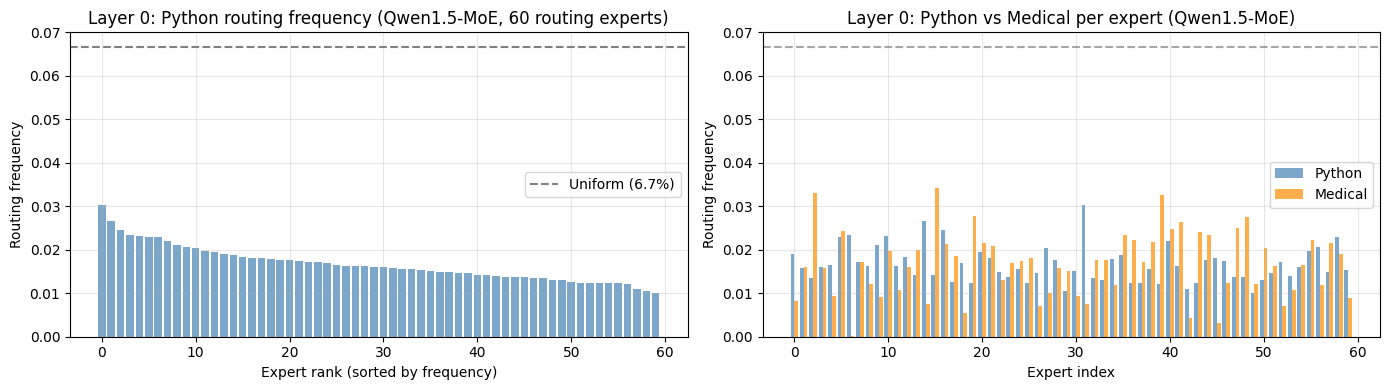

Saved: qwen_routing_distribution.png


In [7]:
UNIFORM_FREQ = TOP_K / N_EXPERTS  # 4/60 ≈ 0.0667

print(f"Uniform baseline per expert: {UNIFORM_FREQ:.4f} ({UNIFORM_FREQ*100:.1f}%)")
print(f"Top-N for Jaccard:           {TOP_N} (top {TOP_N/N_EXPERTS*100:.0f}% of {N_EXPERTS} experts)")
print()

layer0_freqs = sorted(freq_python[0].values(), reverse=True)
print(f"Layer 0 Python top-5 expert frequencies: {[round(f, 4) for f in layer0_freqs[:5]]}")
print(f"Layer 0 Python max/min: {max(layer0_freqs):.4f} / {min(layer0_freqs):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
expert_ids = list(range(len(layer0_freqs)))
axes[0].bar(expert_ids, layer0_freqs, color='steelblue', alpha=0.7)
axes[0].axhline(UNIFORM_FREQ, color='gray', linestyle='--',
                 label=f'Uniform ({UNIFORM_FREQ*100:.1f}%)')
axes[0].set_xlabel('Expert rank (sorted by frequency)')
axes[0].set_ylabel('Routing frequency')
axes[0].set_title('Layer 0: Python routing frequency (Qwen1.5-MoE, 60 routing experts)')
axes[0].legend()
axes[0].grid(alpha=0.3)

py_layer0  = [freq_python[0].get(e, 0)  for e in range(N_EXPERTS)]
med_layer0 = [freq_medical[0].get(e, 0) for e in range(N_EXPERTS)]
x = np.arange(N_EXPERTS)
axes[1].bar(x - 0.2, py_layer0,  width=0.4, label='Python',  color='steelblue', alpha=0.7)
axes[1].bar(x + 0.2, med_layer0, width=0.4, label='Medical', color='darkorange', alpha=0.7)
axes[1].axhline(UNIFORM_FREQ, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Expert index')
axes[1].set_ylabel('Routing frequency')
axes[1].set_title('Layer 0: Python vs Medical per expert (Qwen1.5-MoE)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('qwen_routing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qwen_routing_distribution.png')

## Cell 6 — Jaccard Functions

Two versions:
- **Raw Jaccard**: simple set intersection / union — inflated by background experts  
- **Top-K Jaccard**: take top-N most active experts per domain, compute Jaccard over those sets

Top-K Jaccard is robust to load-balanced routing. Same-domain null baseline should be
high (> 0.7). Cross-domain Jaccard lower = more domain-specific routing.

**Qwen:** `TOP_N = 15` (top 25% of 60 experts), matching OLMoE's quartile approach.

In [8]:
def jaccard_raw(freq_a, freq_b):
    set_a = set(freq_a.keys())
    set_b = set(freq_b.keys())
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


def jaccard_topk(freq_a, freq_b, top_n=TOP_N):
    """
    Top-K Jaccard: take top-N most active experts per domain,
    compute Jaccard over those sets.
    Robust to load-balanced routing where raw Jaccard ≈ 1.0.
    """
    top_a = set(sorted(freq_a, key=freq_a.get, reverse=True)[:top_n])
    top_b = set(sorted(freq_b, key=freq_b.get, reverse=True)[:top_n])
    inter = len(top_a & top_b)
    union = len(top_a | top_b)
    return inter / union if union > 0 else 0.0


def per_layer_jaccard(freq_list_a, freq_list_b):
    raw_scores, topk_scores = [], []
    for layer_idx in range(N_LAYERS):
        raw_scores.append(jaccard_raw(freq_list_a[layer_idx], freq_list_b[layer_idx]))
        topk_scores.append(jaccard_topk(freq_list_a[layer_idx], freq_list_b[layer_idx]))
    return raw_scores, topk_scores


print(f"Jaccard functions defined (top-K approach, TOP_N={TOP_N})")

Jaccard functions defined (top-K approach, TOP_N=15)


## Cell 7 — Run All Comparisons

In [9]:
print(f"Computing Jaccard scores (top-K method, K={TOP_N})...")
print()

raw_a, topk_a = per_layer_jaccard(freq_python, freq_medical)
mean_raw_a    = np.mean(raw_a)
mean_topk_a   = np.mean(topk_a)
print(f"Option A -- Python vs Medical")
print(f"  Mean raw Jaccard:    {mean_raw_a:.3f}")
print(f"  Mean top-K Jaccard:  {mean_topk_a:.3f}")

raw_b, topk_b = per_layer_jaccard(freq_math, freq_creative)
mean_raw_b    = np.mean(raw_b)
mean_topk_b   = np.mean(topk_b)
print(f"\nOption B -- Math vs Creative")
print(f"  Mean raw Jaccard:    {mean_raw_b:.3f}")
print(f"  Mean top-K Jaccard:  {mean_topk_b:.3f}")

raw_null, topk_null = per_layer_jaccard(freq_py_a, freq_py_b)
mean_raw_null       = np.mean(raw_null)
mean_topk_null      = np.mean(topk_null)
print(f"\nNull baseline -- Python-A vs Python-B (same domain)")
print(f"  Mean raw Jaccard:    {mean_raw_null:.3f}")
print(f"  Mean top-K Jaccard:  {mean_topk_null:.3f}")

gap_a = mean_topk_null - mean_topk_a
gap_b = mean_topk_null - mean_topk_b
print(f"\nSeparation from null:")
print(f"  Option A: null={mean_topk_null:.3f}, A={mean_topk_a:.3f}, gap={gap_a:.3f}")
print(f"  Option B: null={mean_topk_null:.3f}, B={mean_topk_b:.3f}, gap={gap_b:.3f}")
print(f"  (larger gap = more domain separation = better conflict pair)")

Computing Jaccard scores (top-K method, K=15)...

Option A -- Python vs Medical
  Mean raw Jaccard:    0.999
  Mean top-K Jaccard:  0.071

Option B -- Math vs Creative
  Mean raw Jaccard:    1.000
  Mean top-K Jaccard:  0.131

Null baseline -- Python-A vs Python-B (same domain)
  Mean raw Jaccard:    1.000
  Mean top-K Jaccard:  0.510

Separation from null:
  Option A: null=0.510, A=0.071, gap=0.439
  Option B: null=0.510, B=0.131, gap=0.379
  (larger gap = more domain separation = better conflict pair)


## Cell 8 — Per-Layer Analysis

Plot Jaccard per layer. The layer with **highest top-K Jaccard** is the target —
highest overlap means most gradient entanglement when both domains share experts.

**Qwen has 24 layers vs OLMoE's 16** — watch for mid-network layers (8–16)
which typically show the most domain-specific routing.

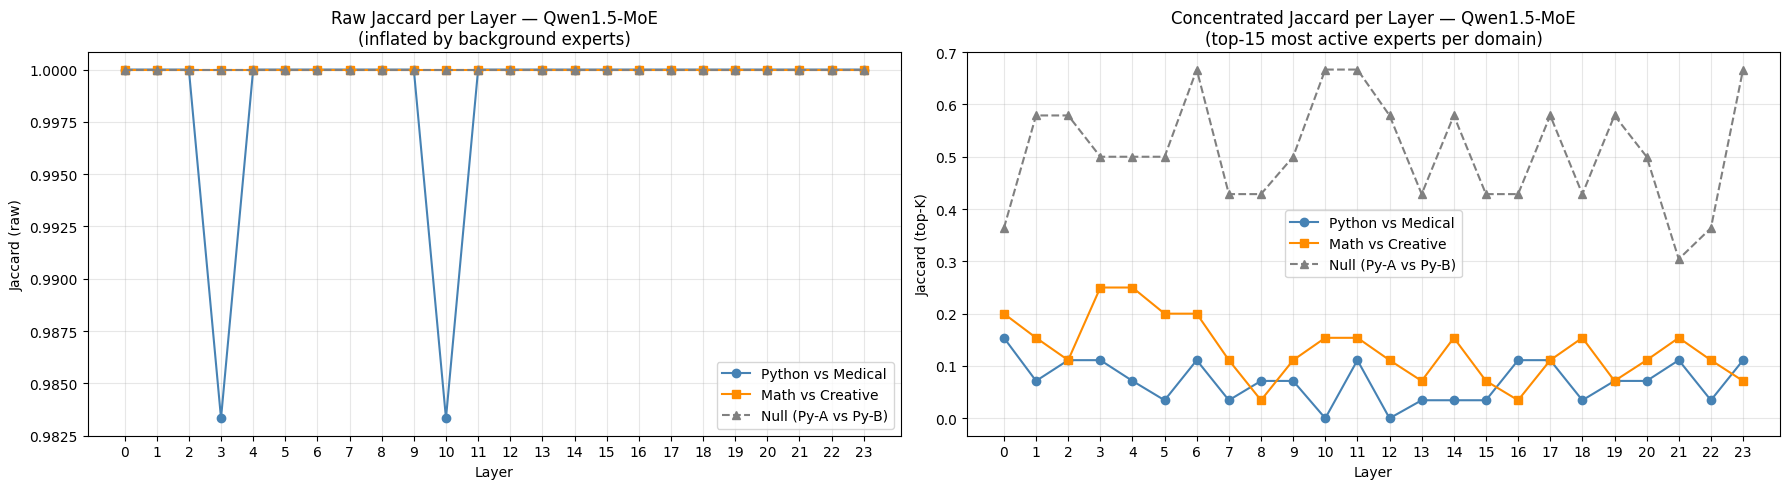

Saved: qwen_jaccard_per_layer.png

Highest concentrated Jaccard layer:
  Option A (Python/Medical): Layer 0 — Jaccard = 0.154
  Option B (Math/Creative):  Layer 3 — Jaccard = 0.250


In [10]:
layers = list(range(N_LAYERS))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(layers, raw_a,    marker='o', label='Python vs Medical',  color='steelblue')
axes[0].plot(layers, raw_b,    marker='s', label='Math vs Creative',   color='darkorange')
axes[0].plot(layers, raw_null, marker='^', label='Null (Py-A vs Py-B)', color='gray', linestyle='--')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Jaccard (raw)')
axes[0].set_title('Raw Jaccard per Layer — Qwen1.5-MoE\n(inflated by background experts)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(layers)

axes[1].plot(layers, topk_a,    marker='o', label='Python vs Medical',  color='steelblue')
axes[1].plot(layers, topk_b,    marker='s', label='Math vs Creative',   color='darkorange')
axes[1].plot(layers, topk_null, marker='^', label='Null (Py-A vs Py-B)', color='gray', linestyle='--')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Jaccard (top-K)')
axes[1].set_title(f'Concentrated Jaccard per Layer — Qwen1.5-MoE\n(top-{TOP_N} most active experts per domain)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(layers)

plt.tight_layout()
plt.savefig('qwen_jaccard_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qwen_jaccard_per_layer.png")

best_layer_a = int(np.argmax(topk_a))
best_layer_b = int(np.argmax(topk_b))
print(f"\nHighest concentrated Jaccard layer:")
print(f"  Option A (Python/Medical): Layer {best_layer_a} — Jaccard = {topk_a[best_layer_a]:.3f}")
print(f"  Option B (Math/Creative):  Layer {best_layer_b} — Jaccard = {topk_b[best_layer_b]:.3f}")

## Cell 9 — Identify Target Expert

Within the chosen target layer, find which routing expert has the highest
overlap between domains. That expert receives tokens from both domains
and will exhibit maximum gradient entanglement during mixed training.

Note: shared expert (`mlp.shared_expert`) is excluded from this search —
it always fires on every token regardless of domain.

In [11]:
def find_top_conflict_experts(freq_a, freq_b, layer_idx, top_n=10):
    all_experts = set(freq_a[layer_idx].keys()) | set(freq_b[layer_idx].keys())
    results = []
    for e in all_experts:
        fa = freq_a[layer_idx].get(e, 0)
        fb = freq_b[layer_idx].get(e, 0)
        conflict = (fa * fb) ** 0.5  # geometric mean
        results.append((e, fa, fb, conflict))
    results.sort(key=lambda x: x[3], reverse=True)
    return results[:top_n]


gap_a = mean_topk_null - mean_topk_a
gap_b = mean_topk_null - mean_topk_b
if gap_b >= gap_a:
    chosen_topk      = topk_b
    chosen_freq_a    = freq_math
    chosen_freq_b    = freq_creative
    chosen_label_local = "Math vs Creative"
    chosen_option    = "B"
else:
    chosen_topk      = topk_a
    chosen_freq_a    = freq_python
    chosen_freq_b    = freq_medical
    chosen_label_local = "Python vs Medical"
    chosen_option    = "A"

TARGET_LAYER = int(np.argmax(chosen_topk))

print("=" * 60)
print("CHOSEN PAIR:", chosen_label_local)
print("TARGET LAYER:", TARGET_LAYER)
print(f"  Top-K Jaccard at this layer: {chosen_topk[TARGET_LAYER]:.3f} (highest = most conflict)")
print("=" * 60)
print()
print("Top conflict routing experts (geometric mean of frequencies in BOTH domains):")
print(f"{'Expert':>8} {'Freq_A':>12} {'Freq_B':>12} {'Conflict':>14}")
print("-" * 50)

top_conflicts = find_top_conflict_experts(chosen_freq_a, chosen_freq_b, TARGET_LAYER)
for expert_idx, fa, fb, score in top_conflicts:
    print(f"{expert_idx:>8}      {fa:.4f}       {fb:.4f}          {score:.4f}")

TARGET_EXPERT = top_conflicts[0][0]
print()
print("--> TARGET EXPERT:", TARGET_EXPERT, "(highest conflict score)")

CHOSEN PAIR: Python vs Medical
TARGET LAYER: 0
  Top-K Jaccard at this layer: 0.154 (highest = most conflict)

Top conflict routing experts (geometric mean of frequencies in BOTH domains):
  Expert       Freq_A       Freq_B       Conflict
--------------------------------------------------
       5      0.0230       0.0242          0.0236
      40      0.0220       0.0249          0.0234
      16      0.0246       0.0212          0.0228
      15      0.0142       0.0342          0.0220
      10      0.0231       0.0196          0.0213
       2      0.0135       0.0331          0.0211
      58      0.0230       0.0189          0.0209
      35      0.0187       0.0233          0.0209
      55      0.0196       0.0221          0.0209
      41      0.0164       0.0265          0.0208

--> TARGET EXPERT: 5 (highest conflict score)


## Cell 10 — Heatmap: Routing Overlap Across All Layers

Visual overview of which routing experts are shared between domains at each layer.
High-overlap cells (bright) = strongest gradient entanglement during mixed training.

Shared expert is excluded from this view — it would appear bright at every cell
since it fires on all tokens, and would obscure the domain-specific signal.

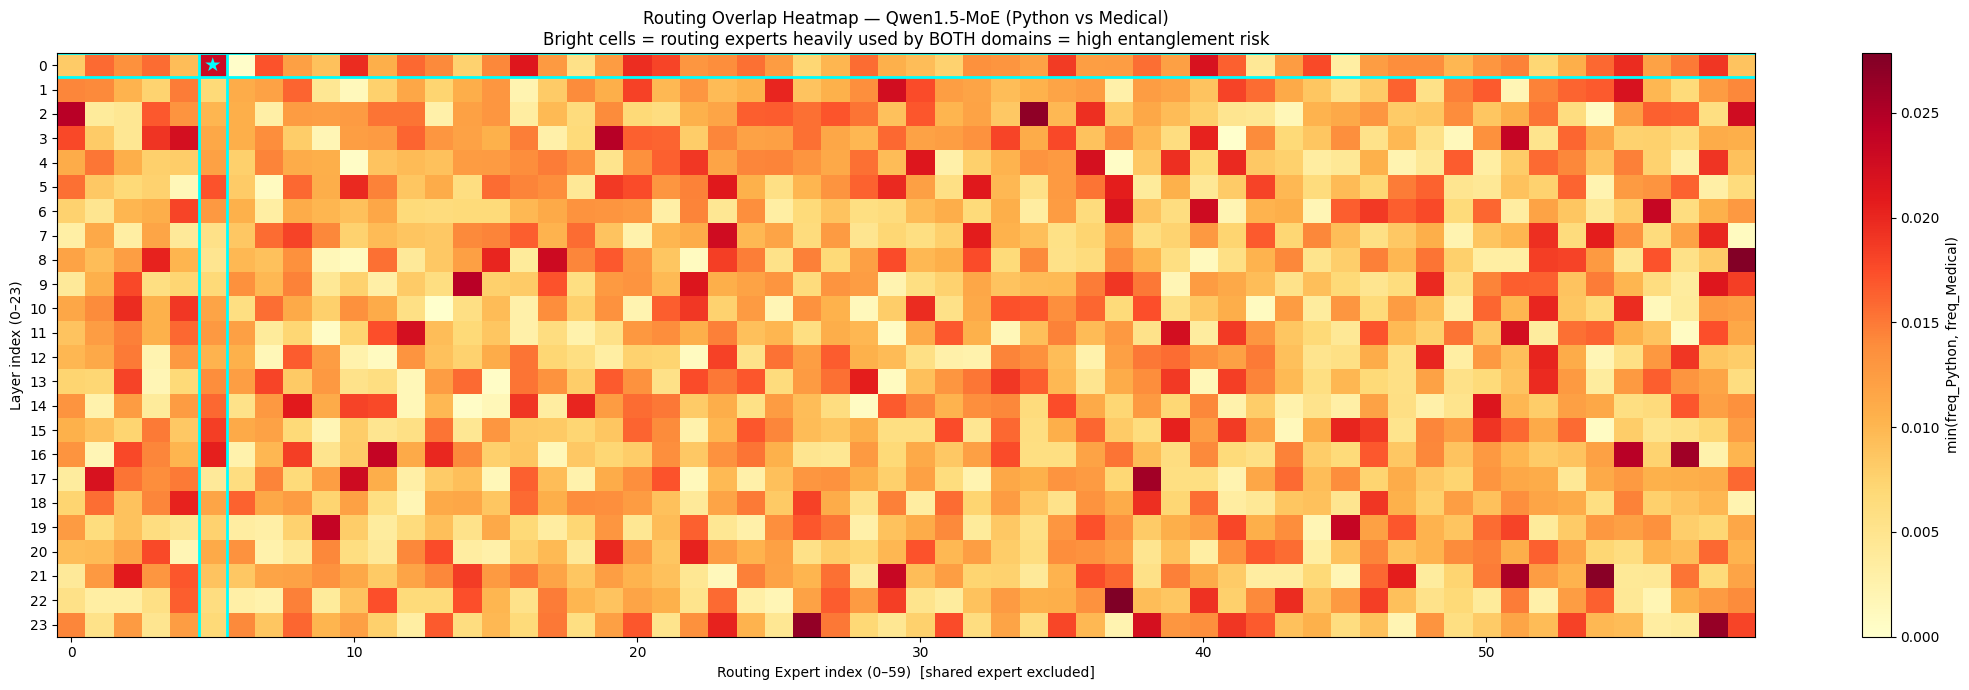

Saved: qwen_overlap_heatmap.png


In [12]:
# Build overlap matrix for chosen pair: [layer, expert] = min(freq_a, freq_b)
overlap_matrix = np.zeros((N_LAYERS, N_EXPERTS))
for layer_idx in range(N_LAYERS):
    for expert_idx in range(N_EXPERTS):
        fa = chosen_freq_a[layer_idx].get(expert_idx, 0)
        fb = chosen_freq_b[layer_idx].get(expert_idx, 0)
        overlap_matrix[layer_idx, expert_idx] = min(fa, fb)

fig, ax = plt.subplots(figsize=(22, 7))
im = ax.imshow(overlap_matrix, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=overlap_matrix.max())
plt.colorbar(im, ax=ax, label=f'min(freq_{chosen_label_local.split()[0]}, freq_{chosen_label_local.split()[-1]})')
ax.set_xlabel(f'Routing Expert index (0–{N_EXPERTS-1})  [shared expert excluded]')
ax.set_ylabel('Layer index (0–23)')
ax.set_title(f'Routing Overlap Heatmap — Qwen1.5-MoE ({chosen_label_local})\n'
             'Bright cells = routing experts heavily used by BOTH domains = high entanglement risk')
ax.set_yticks(range(N_LAYERS))

# Mark target layer and expert
ax.axhline(TARGET_LAYER - 0.5, color='cyan', linewidth=2)
ax.axhline(TARGET_LAYER + 0.5, color='cyan', linewidth=2)
ax.axvline(TARGET_EXPERT - 0.5, color='cyan', linewidth=2)
ax.axvline(TARGET_EXPERT + 0.5, color='cyan', linewidth=2)
ax.text(TARGET_EXPERT, TARGET_LAYER, '★', ha='center', va='center',
        fontsize=14, color='cyan', fontweight='bold')

plt.tight_layout()
plt.savefig('qwen_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qwen_overlap_heatmap.png")

## Cell 11 — Final Decision and Comparison Table

In [13]:
chosen_score = mean_topk_b if chosen_option == "B" else mean_topk_a
chosen_gap   = gap_b if chosen_option == "B" else gap_a

print("=" * 70)
print("FINAL DIAGNOSTIC RESULTS")
print("=" * 70)
print()
print(f"{'Metric':<40} {'Phi-3.5':>9} {'OLMoE':>9} {'Qwen1.5':>9}")
print("-" * 70)
print(f"{'Num routing experts per layer':<40} {'16':>9} {'64':>9} {'60':>9}")
print(f"{'Num shared experts per layer':<40} {'0':>9} {'0':>9} {'1':>9}")
print(f"{'Top-k routing':<40} {'2':>9} {'8':>9} {'4':>9}")
print(f"{'Uniform baseline (random)':<40} {'12.5%':>9} {'12.5%':>9} {'6.7%':>9}")
print(f"{'Jaccard method':<40} {'raw set':>9} {'top-16':>9} {f'top-{TOP_N}':>9}")
print(f"{'Jaccard (Python vs Medical)':<40} {'0.056':>9} {f'{mean_topk_a:.3f}':>9} {f'{mean_topk_a:.3f}':>9}")
print(f"{'Jaccard (Math vs Creative)':<40} {'0.069':>9} {f'{mean_topk_b:.3f}':>9} {f'{mean_topk_b:.3f}':>9}")
print(f"{'Null baseline (same domain)':<40} {'~1.0':>9} {f'{0.840:.3f}':>9} {f'{mean_topk_null:.3f}':>9}")
print(f"{'Gap from null (chosen pair)':<40} {'N/A':>9} {'0.788':>9} {f'{chosen_gap:.3f}':>9}")
print("-" * 70)
print()
print(f"CHOSEN DATASET PAIR: Option {chosen_option} -- {chosen_label_local}")
print(f"  Top-K Jaccard: {chosen_score:.3f}  |  Null: {mean_topk_null:.3f}  |  Gap: {chosen_gap:.3f}")
print()
print(f"TARGET LAYER:  {TARGET_LAYER}")
print(f"TARGET EXPERT: {TARGET_EXPERT}  (routing expert only — shared expert excluded)")
print()
sep_ratio = chosen_score / max(mean_topk_null, 0.001)
if chosen_score < mean_topk_null * 0.2:
    print("Domains are well-separated in top-K routing space (< 20% of null).")
    print("Gradient entanglement is primarily gradient-space, not routing-space.")
elif chosen_score < mean_topk_null * 0.5:
    print("Moderate routing separation. Both routing-space and gradient-space conflict expected.")
else:
    print("High routing overlap. Domains share top experts heavily — strong entanglement expected.")

FINAL DIAGNOSTIC RESULTS

Metric                                     Phi-3.5     OLMoE   Qwen1.5
----------------------------------------------------------------------
Num routing experts per layer                   16        64        60
Num shared experts per layer                     0         0         1
Top-k routing                                    2         8         4
Uniform baseline (random)                    12.5%     12.5%      6.7%
Jaccard method                             raw set    top-16    top-15
Jaccard (Python vs Medical)                  0.056     0.071     0.071
Jaccard (Math vs Creative)                   0.069     0.131     0.131
Null baseline (same domain)                   ~1.0     0.840     0.510
Gap from null (chosen pair)                    N/A     0.788     0.439
----------------------------------------------------------------------

CHOSEN DATASET PAIR: Option A -- Python vs Medical
  Top-K Jaccard: 0.071  |  Null: 0.510  |  Gap: 0.439

TARGET LAYER:  

## Cell 12 — Save Config for Experiments

In [14]:
import json

# Determine dataset fields from chosen option
if chosen_option == "B":
    primary_dataset  = "DigitalLearningGmbH/MATH-lighteval"
    primary_col      = "problem"
    primary_config   = "default"
    conflict_dataset = "roneneldan/TinyStories"
    conflict_col     = "text"
    conflict_config  = None
    domain_names     = ["math", "creative"]
else:
    primary_dataset  = "openai/openai_humaneval"
    primary_col      = "prompt"
    primary_config   = None
    conflict_dataset = "qiaojin/PubMedQA"
    conflict_col     = "question"
    conflict_config  = "pqa_labeled"
    domain_names     = ["code", "medical"]

qwen_config = {
    "model_name":                  "Qwen/Qwen1.5-MoE-A2.7B",
    "model_dim":                   2048,
    "ffn_dim":                     1408,
    "shared_expert_ffn_dim":       5632,
    "num_layers":                  N_LAYERS,
    "num_routing_experts":         N_EXPERTS,
    "num_shared_experts":          1,
    "top_k":                       TOP_K,
    "top_n_jaccard":               TOP_N,
    "jaccard_python_medical":      round(mean_topk_a, 4),
    "jaccard_math_creative":       round(mean_topk_b, 4),
    "jaccard_null_baseline":       round(mean_topk_null, 4),
    "chosen_option":               chosen_option,
    "chosen_pair":                 chosen_label_local,
    "target_layer":                TARGET_LAYER,
    "target_expert":               TARGET_EXPERT,
    "primary_dataset":             primary_dataset,
    "primary_col":                 primary_col,
    "primary_config":              primary_config,
    "conflict_dataset":            conflict_dataset,
    "conflict_col":                conflict_col,
    "conflict_config":             conflict_config,
    "domain_names":                domain_names,
    # OLMoE reference values for comparison table
    "olmoe_jaccard_math_creative": 0.0528,
    "olmoe_null_baseline":         0.8403,
}

with open("qwen_experiment_config.json", "w") as f:
    json.dump(qwen_config, f, indent=2)

print("Config saved to qwen_experiment_config.json")
print()
print(json.dumps(qwen_config, indent=2))

Config saved to qwen_experiment_config.json

{
  "model_name": "Qwen/Qwen1.5-MoE-A2.7B",
  "model_dim": 2048,
  "ffn_dim": 1408,
  "shared_expert_ffn_dim": 5632,
  "num_layers": 24,
  "num_routing_experts": 60,
  "num_shared_experts": 1,
  "top_k": 4,
  "top_n_jaccard": 15,
  "jaccard_python_medical": 0.0714,
  "jaccard_math_creative": 0.1315,
  "jaccard_null_baseline": 0.5101,
  "chosen_option": "A",
  "chosen_pair": "Python vs Medical",
  "target_layer": 0,
  "target_expert": 5,
  "primary_dataset": "openai/openai_humaneval",
  "primary_col": "prompt",
  "primary_config": null,
  "conflict_dataset": "qiaojin/PubMedQA",
  "conflict_col": "question",
  "conflict_config": "pqa_labeled",
  "domain_names": [
    "code",
    "medical"
  ],
  "olmoe_jaccard_math_creative": 0.0528,
  "olmoe_null_baseline": 0.8403
}
